# Neural PDE Laboratory · 03
## Inverse diffusion and sensor placement

Experiments **6** of the laboratory. This notebook is self-contained:
run it in a fresh kernel; no earlier notebook or saved result is required.

[All seven notebooks](Neural_PDE_Laboratory.ipynb) · [Setup and guide](NOTEBOOK_README.md)

Install `experiments/requirements-notebook.txt`, then select **Restart Kernel and
Run All Cells**. The supplied static plots and diagnostics can be read on GitHub.
Interactive explorers are separate, self-contained HTML files in `notebook_outputs/`;
download that folder and open `index.html` in a browser, or regenerate them locally.

Python 3.11+; CPU / float64. Set `RUN_MODE = "thorough"` for longer training runs.

**Notation:** $u$ is the reference state, $u_\theta$ the neural state,
$r_\theta=\mathcal L u_\theta-f$, $\mathcal J$ a continuous residual loss,
$\widehat{\mathcal J}$ its numerical approximation, and $\mathcal E$ an energy.
A hat indicates sampling or quadrature. We check solution error separately from training loss.

In [1]:
# Uncomment only if these packages are missing, then restart the kernel.
# %pip install "numpy>=2.0" scipy matplotlib "torch>=2.2" "plotly>=5.24,<7" ipython

In [2]:
from pathlib import Path
import copy, io, json, math, platform, time
import numpy as np
import scipy
from scipy.linalg import solve_banded
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
import torch
from torch import nn
import plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, Markdown, Image

RUN_MODE = "quick"               # "quick" or "thorough"
SEED = 7
OUTPUT_DIR = Path.cwd() / "notebook_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
NOTEBOOK_START = time.perf_counter()
metrics = []
FIGURE_NAMES, INTERACTIVE_NAMES = [], []
assert RUN_MODE in {"quick", "thorough"}
torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
torch.manual_seed(SEED)
np.random.seed(SEED)
BUDGET = {"adam_1d": 900, "lbfgs_1d": 180, "adam_2d": 1100,
          "lbfgs_2d": 260, "boundary_adam": 900}
if RUN_MODE == "thorough":
    BUDGET = {key: 2 * value for key, value in BUDGET.items()}
versions = {"python": platform.python_version(), "numpy": np.__version__,
            "scipy": scipy.__version__, "matplotlib": matplotlib.__version__,
            "torch": torch.__version__, "plotly": plotly.__version__}
print(json.dumps(versions, indent=2))
print(f"CPU / float64 / seed {SEED} / {RUN_MODE} mode")

{
  "python": "3.13.9",
  "numpy": "2.4.2",
  "scipy": "1.17.0",
  "matplotlib": "3.10.8",
  "torch": "2.10.0",
  "plotly": "6.9.0"
}
CPU / float64 / seed 7 / quick mode


## Reading and saving the plots

Static figures are saved as PNG and PDF and embedded in this notebook. Interactive
plots are saved as offline HTML files: open their links locally to rotate, zoom,
and animate them. GitHub displays the static figures without executing JavaScript.

In [3]:
palette = {"navy": "#10243A", "teal": "#00A6A6", "orange": "#F28C45",
           "pink": "#DC4778", "blue": "#4878D0", "ink": "#183449", "muted": "#63788A"}
plt.rcParams.update({
    "figure.facecolor": "#F7FAFC", "axes.facecolor": "#F7FAFC",
    "axes.edgecolor": "#CAD6DF", "axes.labelcolor": palette["ink"],
    "text.color": palette["ink"], "xtick.color": palette["muted"],
    "ytick.color": palette["muted"], "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": "#DCE5EB", "grid.alpha": 0.65,
    "lines.linewidth": 2.3, "figure.dpi": 110, "savefig.dpi": 170,
    "legend.frameon": False, "font.family": "DejaVu Sans",
    "axes.prop_cycle": matplotlib.cycler(color=[palette[k] for k in
                                  ["teal", "orange", "pink", "blue", "navy"]]),
})
sea_cmap = LinearSegmentedColormap.from_list("sea", ["#10243A", "#146F88", "#00BBB0", "#F9D879"])
wave_scale = [[0, "#153F7C"], [.25, "#21A9B5"], [.5, "#F7FAFC"],
              [.75, "#FFB16E"], [1, "#C93663"]]

def style_3d(ax, title=None):
    if title:
        ax.set_title(title)
    ax.view_init(elev=28, azim=-128)
    ax.set_box_aspect((1, 1, .65))
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis._axinfo["grid"]["color"] = (0.78, 0.84, 0.88, 0.35)
    ax.tick_params(labelsize=8, pad=1)

def save_figure(fig, name):
    if name not in FIGURE_NAMES:
        FIGURE_NAMES.append(name)
    fig.savefig(OUTPUT_DIR / f"{name}.png", bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / f"{name}.pdf", bbox_inches="tight")
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=130, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

def show_interactive(fig, name):
    if name not in INTERACTIVE_NAMES:
        INTERACTIVE_NAMES.append(name)
    fig.update_layout(template="plotly_dark", paper_bgcolor="#10243A",
                      plot_bgcolor="#10243A", font=dict(family="Arial", size=13),
                      margin=dict(l=40, r=55, t=130, b=75), height=680)
    fig.update_layout(title=dict(x=.035, y=.97, xanchor="left", font=dict(size=19)))
    for menu in fig.layout.updatemenus:
        menu.update(y=1.04, yanchor="bottom", x=0, xanchor="left",
                    bgcolor="#E5EFF5", bordercolor="#9FB8CA",
                    font=dict(color="#10243A", size=12))
    fig.update_scenes(bgcolor="#10243A",
        xaxis=dict(backgroundcolor="#10243A", gridcolor="#31506C"),
        yaxis=dict(backgroundcolor="#10243A", gridcolor="#31506C"),
        zaxis=dict(backgroundcolor="#10243A", gridcolor="#31506C"))
    config = {"displaylogo": False, "responsive": True}
    fig.write_html(OUTPUT_DIR / f"{name}.html", include_plotlyjs=True,
                   full_html=True, config=config, auto_play=False)
    # Keep notebook previews small: JavaScript and animation data live in HTML.
    relative = (OUTPUT_DIR / f"{name}.html").relative_to(Path.cwd()).as_posix()
    display(Markdown(f"[Open interactive explorer]({relative}) — "
                     "open locally in a browser; GitHub previews show the static plots."))

def grad_scalar(u, x):
    return torch.autograd.grad(u.sum(), x, create_graph=True)[0]

def mlp(input_dim, width=32, depth=2):
    layers = [nn.Linear(input_dim, width), nn.Tanh()]
    for _ in range(depth - 1):
        layers.extend([nn.Linear(width, width), nn.Tanh()])
    return nn.Sequential(*layers, nn.Linear(width, 1))

def train_model(model, objective, adam_steps, lbfgs_steps=0, diagnostic=None):
    """Log each objective evaluation, including repeated L-BFGS closure calls."""
    start = time.perf_counter()
    history = {"evaluation": [], "loss": [], "error_eval": [], "error": []}
    evaluations = 0
    opt = torch.optim.Adam(model.parameters(), lr=2e-3)
    def evaluate():
        nonlocal evaluations
        value = objective()
        evaluations += 1
        history["evaluation"].append(evaluations)
        history["loss"].append(value.detach().item())
        return value
    for step in range(adam_steps):
        opt.zero_grad(set_to_none=True)
        loss = evaluate()
        loss.backward()
        opt.step()
        if diagnostic is not None and (step == 0 or (step + 1) % 100 == 0):
            history["error_eval"].append(evaluations)
            history["error"].append(diagnostic())
    if lbfgs_steps:
        opt = torch.optim.LBFGS(model.parameters(), max_iter=lbfgs_steps,
                 max_eval=2*lbfgs_steps, history_size=40, line_search_fn="strong_wolfe",
                 tolerance_grad=1e-10, tolerance_change=1e-13)
        def closure():
            opt.zero_grad(set_to_none=True)
            value = evaluate()
            value.backward()
            return value
        opt.step(closure)
    if diagnostic is not None:
        history["error_eval"].append(evaluations)
        history["error"].append(diagnostic())
    history["seconds"] = time.perf_counter() - start
    return history

## 6 · Inverse diffusion: where you measure matters

Use **ten noisy observations** to estimate a positive diffusion coefficient and the corresponding solution:

\[
-\kappa u''=\pi^2\sin(\pi x),\qquad u(0)=u(1)=0,
\qquad u(x)=\frac{\sin(\pi x)}{\kappa},\quad \kappa_{\rm true}=0.7.
\]

Compare well-spread interior sensors with sensors clustered near the boundaries. Both layouts use the same number of sensors, the same absolute noise level, and the same noise vector. A small neural network learns $u_\theta$ and $\kappa$ jointly, using $u_\theta=x(1-x)N_\theta$ to enforce both boundary values. We also fit the exact solution formula by least squares. Comparing the two fits helps separate training error from data uncertainty.

**Before running:** the boundaries fix $u=0$ for *every* coefficient. Measurements close to them carry less information about $\kappa$, even though the data still contain noise.

In [4]:
# One seed, one noise realization, two measurement designs.
inv_rng = np.random.default_rng(23)
inv_kappa_true, inv_sigma = 0.7, 0.02 / 0.7
inv_count = 10
inv_noise = inv_rng.normal(0.0, inv_sigma, inv_count)
inv_layouts = {
    "Interior sensors": np.linspace(0.12, 0.88, inv_count),
    "Boundary clusters": np.r_[np.linspace(0.01, 0.06, 5),
                               np.linspace(0.94, 0.99, 5)],
}
inv_grid = np.linspace(0.0, 1.0, 401)
inv_sine = np.sin(np.pi * inv_grid)
inv_results = {}
for inv_label, inv_x in inv_layouts.items():
    inv_s = np.sin(np.pi * inv_x)
    inv_y = inv_s / inv_kappa_true + inv_noise
    # Let c = 1/kappa: this is a one-parameter linear least-squares problem.
    inv_c = np.dot(inv_s, inv_y) / np.dot(inv_s, inv_s)
    inv_se = inv_sigma / np.sqrt(np.dot(inv_s, inv_s))
    inv_c_bounds = inv_c + np.array([-1.0, 1.0]) * 1.95996398454 * inv_se
    assert inv_c_bounds[0] > 0, "Increase information before inverting this interval."
    inv_results[inv_label] = dict(
        x=inv_x, y=inv_y, c=inv_c, c_bounds=inv_c_bounds,
        kappa_ls=1.0 / inv_c, kappa_ci=1.0 / inv_c_bounds[::-1],
        information=np.dot(inv_s, inv_s) / (inv_sigma**2 * inv_kappa_true**4),
    )
print("Equal data budgets: 10 sensors each; noise SD = %.4f" % inv_sigma)
for inv_label, inv_result in inv_results.items():
    print(f"{inv_label:19s}  kappa = {inv_result['kappa_ls']:.4f}  "
          f"95% interval = {inv_result['kappa_ci'].round(4)}")
print("Information ratio (interior / boundary): %.1f" % (
    inv_results["Interior sensors"]["information"] /
    inv_results["Boundary clusters"]["information"]))

Equal data budgets: 10 sensors each; noise SD = 0.0286
Interior sensors     kappa = 0.7034  95% interval = [0.6921 0.715 ]
Boundary clusters    kappa = 0.7341  95% interval = [0.6638 0.8211]
Information ratio (interior / boundary): 39.2


In [5]:
# Joint neural / coefficient training, starting from identical weights.
# Physics is normalized by pi^2; the data term receives weight 5.
inv_dtype = torch.float64

class inv_PINN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(1, 24), torch.nn.Tanh(),
            torch.nn.Linear(24, 24), torch.nn.Tanh(),
            torch.nn.Linear(24, 1))
        self.log_kappa = torch.nn.Parameter(torch.tensor(np.log(1.1), dtype=inv_dtype))

    @property
    def kappa(self):
        return self.log_kappa.exp()

    def forward(self, x):
        return x * (1.0 - x) * self.net(x)

def inv_train(inv_result):
    torch.manual_seed(23)
    inv_model = inv_PINN().to(dtype=inv_dtype)
    inv_xr = torch.linspace(0, 1, 66, dtype=inv_dtype)[1:-1, None].requires_grad_()
    inv_xd = torch.tensor(inv_result["x"][:, None], dtype=inv_dtype)
    inv_yd = torch.tensor(inv_result["y"][:, None], dtype=inv_dtype)

    def inv_loss():
        inv_u = inv_model(inv_xr)
        inv_du = torch.autograd.grad(inv_u, inv_xr, torch.ones_like(inv_u),
                                     create_graph=True)[0]
        inv_d2u = torch.autograd.grad(inv_du, inv_xr, torch.ones_like(inv_du),
                                      create_graph=True)[0]
        inv_residual = -inv_model.kappa * inv_d2u / np.pi**2 - torch.sin(np.pi * inv_xr)
        return inv_residual.square().mean() + 5.0 * (inv_model(inv_xd) - inv_yd).square().mean()

    inv_history = []
    inv_optimizer = torch.optim.Adam(inv_model.parameters(), lr=0.003)
    for inv_step in range(1000):
        inv_optimizer.zero_grad(set_to_none=True)
        inv_xr.grad = None
        inv_value = inv_loss()
        inv_value.backward()
        inv_optimizer.step()
        if inv_step % 20 == 0:
            inv_history.append((inv_step + 1, inv_model.kappa.item()))
    inv_optimizer = torch.optim.LBFGS(
        inv_model.parameters(), max_iter=140, history_size=30,
        tolerance_grad=1e-10, tolerance_change=1e-12, line_search_fn="strong_wolfe")
    def inv_closure():
        inv_optimizer.zero_grad(set_to_none=True)
        inv_xr.grad = None
        inv_value = inv_loss()
        inv_value.backward()
        return inv_value
    inv_optimizer.step(inv_closure)
    with torch.no_grad():
        inv_prediction = inv_model(torch.tensor(inv_grid[:, None], dtype=inv_dtype)).numpy().ravel()
    return inv_model.kappa.item(), inv_prediction, np.asarray(inv_history)

inv_old_threads = torch.get_num_threads()
torch.set_num_threads(1)
try:
    for inv_label, inv_result in inv_results.items():
        inv_k, inv_prediction, inv_history = inv_train(inv_result)
        inv_result.update(kappa_nn=inv_k, prediction=inv_prediction, history=inv_history)
        inv_error = np.linalg.norm(inv_prediction - inv_sine / inv_kappa_true) / np.linalg.norm(inv_sine / inv_kappa_true)
        print(f"{inv_label:19s}  neural kappa = {inv_k:.4f}  "
              f"reference kappa = {inv_result['kappa_ls']:.4f}  field error = {inv_error:.2%}")
finally:
    torch.set_num_threads(inv_old_threads)

Interior sensors     neural kappa = 0.7029  reference kappa = 0.7034  field error = 0.67%


Boundary clusters    neural kappa = 0.7342  reference kappa = 0.7341  field error = 4.66%


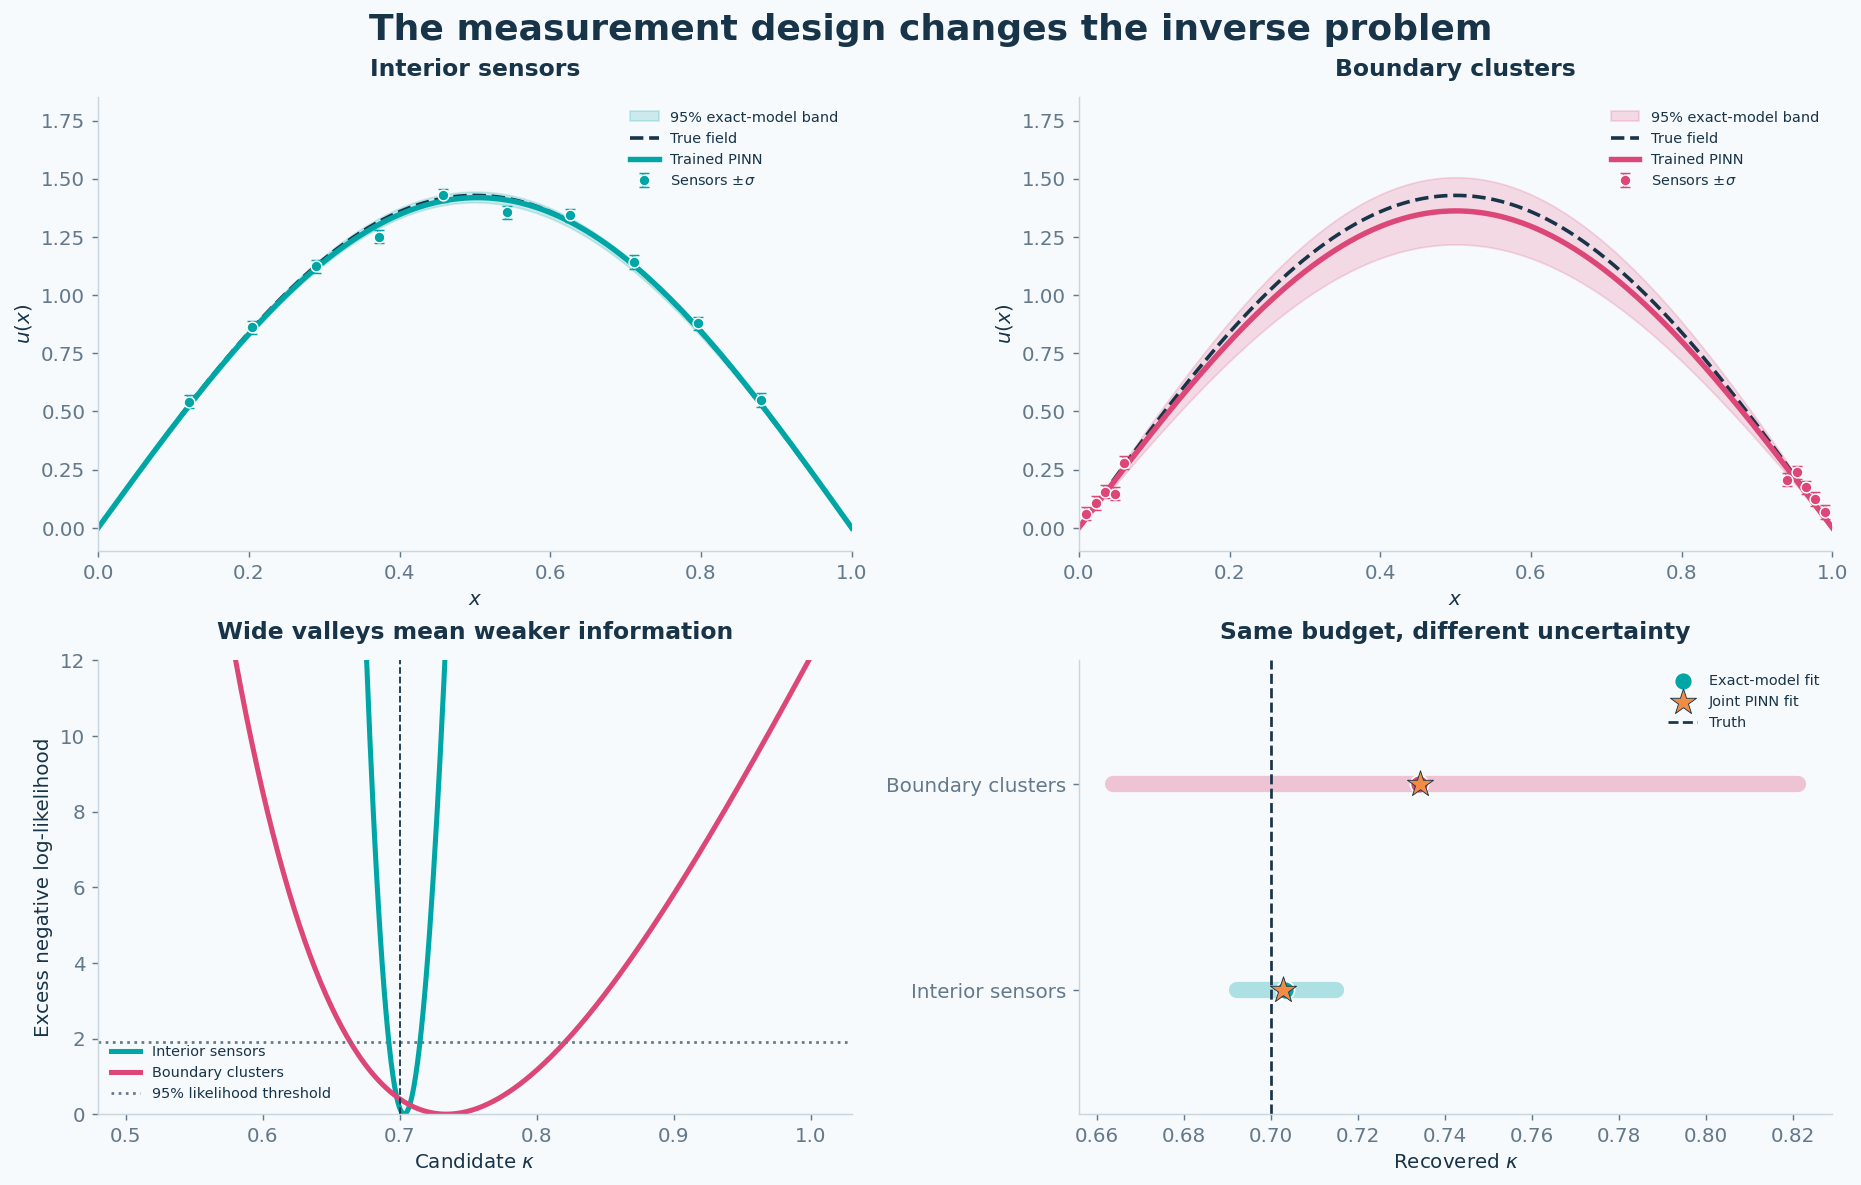

In [6]:
inv_colors = [palette["teal"], palette["pink"]]
inv_fig, inv_axes = plt.subplots(2, 2, figsize=(14.2, 9.0), constrained_layout=True)
for inv_ax, (inv_label, inv_result), inv_color in zip(
        inv_axes[0], inv_results.items(), inv_colors):
    inv_ax.fill_between(inv_grid, inv_sine * inv_result["c_bounds"][0],
                        inv_sine * inv_result["c_bounds"][1], color=inv_color,
                        alpha=0.18, label="95% exact-model band")
    inv_ax.plot(inv_grid, inv_sine / inv_kappa_true, color=palette["ink"], lw=2,
                ls="--", label="True field")
    inv_ax.plot(inv_grid, inv_result["prediction"], color=inv_color, lw=3,
                label="Trained PINN")
    inv_ax.errorbar(inv_result["x"], inv_result["y"], yerr=inv_sigma,
                    fmt="o", ms=6, capsize=3, color=inv_color,
                    mec="white", mew=0.8, label=r"Sensors $\pm\sigma$", zorder=5)
    inv_ax.set(title=inv_label, xlabel="$x$", ylabel="$u(x)$", xlim=(0, 1), ylim=(-0.1, 1.85))
    inv_ax.legend(loc="upper right", fontsize=8)

inv_kgrid = np.linspace(0.35, 1.25, 700)
for (inv_label, inv_result), inv_color in zip(inv_results.items(), inv_colors):
    inv_at_sensors = np.sin(np.pi * inv_result["x"])[None, :] / inv_kgrid[:, None]
    inv_nll = 0.5 * np.sum(((inv_at_sensors - inv_result["y"]) / inv_sigma)**2, axis=1)
    inv_best_nll = 0.5 * np.sum(((inv_result["c"] * np.sin(np.pi * inv_result["x"])
                                - inv_result["y"]) / inv_sigma)**2)
    inv_axes[1, 0].plot(inv_kgrid, inv_nll - inv_best_nll,
                        color=inv_color, lw=2.8, label=inv_label)
inv_axes[1, 0].axhline(1.95996398454**2 / 2, color=palette["muted"], ls=":", lw=1.5,
                      label="95% likelihood threshold")
inv_axes[1, 0].axvline(inv_kappa_true, color=palette["ink"], ls="--", lw=1)
inv_axes[1, 0].set(xlim=(0.48, 1.03), ylim=(0, 12), xlabel=r"Candidate $\kappa$",
                   ylabel="Excess negative log-likelihood", title="Wide valleys mean weaker information")
inv_axes[1, 0].legend(fontsize=8)

for inv_row, ((inv_label, inv_result), inv_color) in enumerate(zip(inv_results.items(), inv_colors)):
    inv_ci = inv_result["kappa_ci"]
    inv_axes[1, 1].plot(inv_ci, [inv_row, inv_row], lw=9, solid_capstyle="round", color=inv_color, alpha=0.3)
    inv_axes[1, 1].scatter(inv_result["kappa_ls"], inv_row, s=100, color=inv_color,
                          edgecolor="white", zorder=4, label="Exact-model fit" if inv_row == 0 else None)
    inv_axes[1, 1].scatter(inv_result["kappa_nn"], inv_row, marker="*", s=230,
                          color=palette["orange"], edgecolor=palette["ink"], linewidth=0.5,
                          zorder=5, label="Joint PINN fit" if inv_row == 0 else None)
inv_axes[1, 1].axvline(inv_kappa_true, color=palette["ink"], ls="--", lw=1.5, label="Truth")
inv_axes[1, 1].set(yticks=[0, 1], yticklabels=list(inv_results), ylim=(-0.6, 1.6),
                  xlabel=r"Recovered $\kappa$", title="Same budget, different uncertainty")
inv_axes[1, 1].legend(loc="upper right", fontsize=8)
inv_fig.suptitle("The measurement design changes the inverse problem", fontsize=20, weight="bold")
save_figure(inv_fig, "inverse_sensor_design")

### What can the observations tell us?

For independent Gaussian noise of known standard deviation $\sigma$, set $s_i=\sin(\pi x_i)$ and $c=1/\kappa$. Then

\[
\widehat c=\frac{\sum_i s_i y_i}{\sum_i s_i^2},\qquad
\operatorname{sd}(\widehat c)=\frac{\sigma}{\sqrt{\sum_i s_i^2}},\qquad
I(\kappa)=\frac{\sum_i\sin^2(\pi x_i)}{\sigma^2\kappa^4}.
\]

We obtain the plotted intervals from the **exact forward model** by transforming a Gaussian interval for $c$. They describe uncertainty in that fit, rather than in the neural prediction. The PINN can give a different estimate because its loss includes a sampled, weighted PDE residual and training stops after a fixed number of steps.

Now free the forcing amplitude too: $-\kappa u''=a\pi^2\sin(\pi x)$. The solution becomes $u=(a/\kappa)\sin(\pi x)$. Even perfect observations determine only the ratio $a/\kappa$. The second 3D plot shows the resulting valley. To identify both parameters, we need an additional kind of measurement.

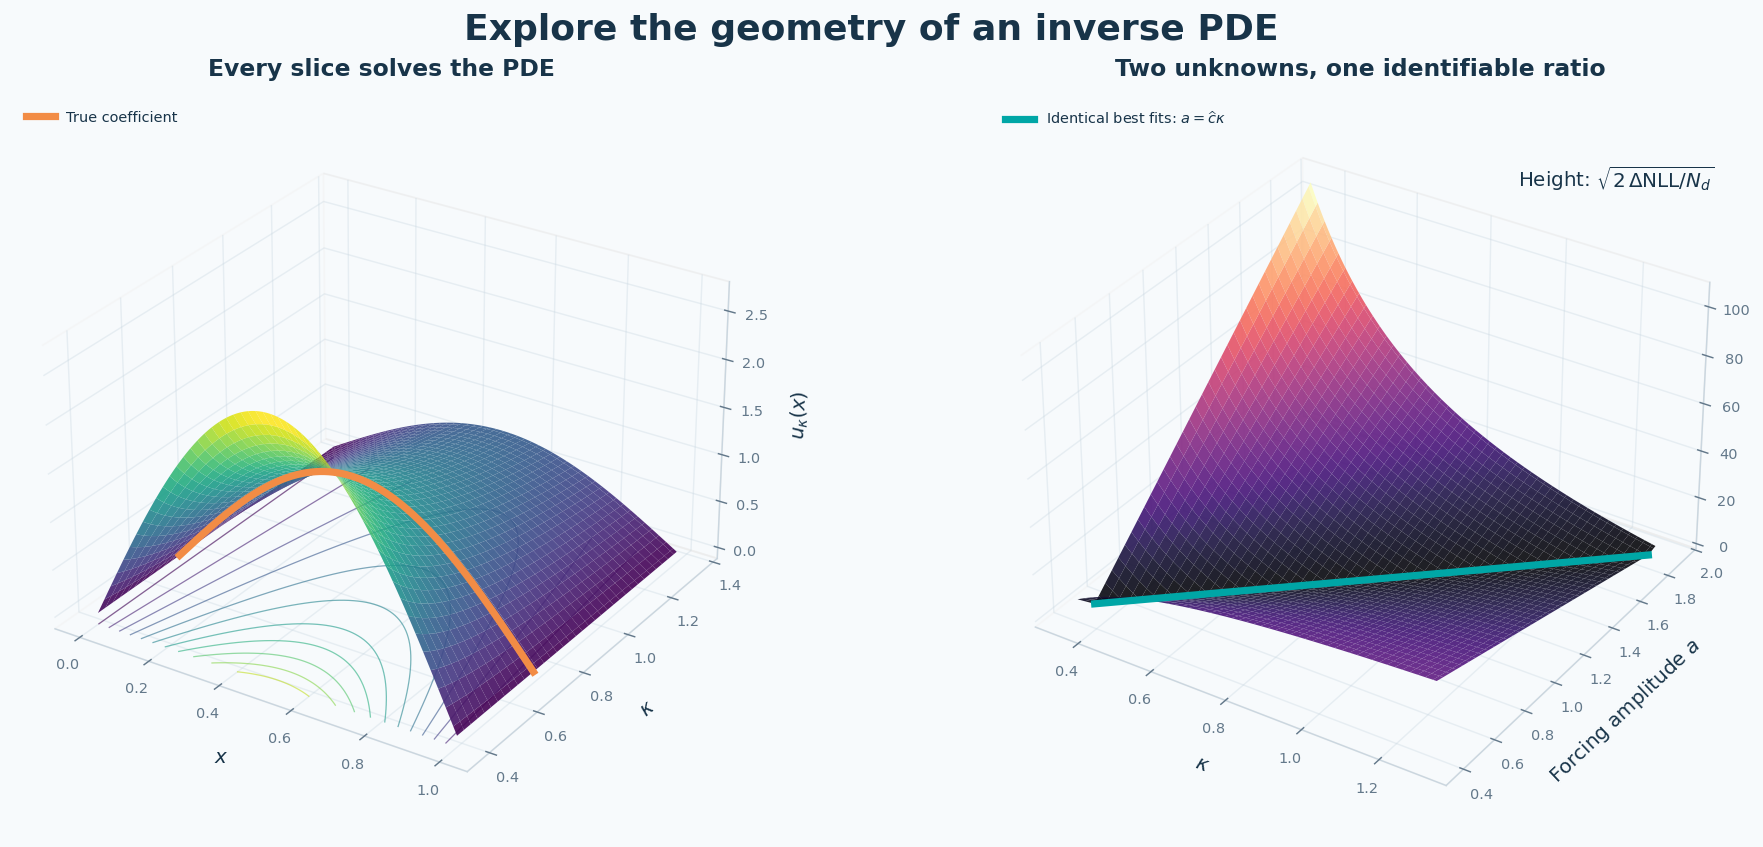

In [7]:
# 3D geometry: the forward solution family and a two-parameter inverse valley.
inv_fig = plt.figure(figsize=(15.0, 6.4), constrained_layout=True)
inv_ax_family = inv_fig.add_subplot(121, projection="3d")
inv_ax_valley = inv_fig.add_subplot(122, projection="3d")
inv_ax_family.computed_zorder = False
inv_ax_valley.computed_zorder = False
inv_family_k = np.linspace(0.38, 1.35, 70)
inv_X, inv_K = np.meshgrid(np.linspace(0, 1, 100), inv_family_k)
inv_U = np.sin(np.pi * inv_X) / inv_K
inv_surface = inv_ax_family.plot_surface(inv_X, inv_K, inv_U, cmap="viridis",
                                          linewidth=0, antialiased=True, alpha=0.90, zorder=2)
inv_ax_family.plot(inv_grid, np.full_like(inv_grid, inv_kappa_true), inv_sine / inv_kappa_true,
                    color=palette["orange"], lw=4, label="True coefficient", zorder=8)
inv_ax_family.contour(inv_X, inv_K, inv_U, zdir="z", offset=-0.12, levels=10,
                       cmap="viridis", linewidths=0.7, alpha=0.6, zorder=1)
inv_ax_family.set(xlabel="$x$", ylabel=r"$\kappa$", zlabel=r"$u_\kappa(x)$", zlim=(-0.12, 2.8))
style_3d(inv_ax_family, title="Every slice solves the PDE")
inv_ax_family.view_init(elev=28, azim=-57)
inv_ax_family.legend(loc="upper left", fontsize=8)

inv_ref = inv_results["Interior sensors"]
inv_K2, inv_A = np.meshgrid(np.linspace(0.35, 1.3, 100), np.linspace(0.4, 1.9, 110))
inv_prediction_family = (inv_A / inv_K2)[..., None] * np.sin(np.pi * inv_ref["x"])
inv_loss_surface = 0.5 * np.sum(((inv_prediction_family - inv_ref["y"]) / inv_sigma)**2, axis=-1)
inv_loss_min = 0.5 * np.sum(((inv_ref["c"] * np.sin(np.pi * inv_ref["x"])
                             - inv_ref["y"]) / inv_sigma)**2)
inv_Z = np.sqrt(2.0 * np.maximum(inv_loss_surface - inv_loss_min, 0.0) / inv_count)
inv_surface = inv_ax_valley.plot_surface(inv_K2, inv_A, inv_Z, cmap="magma",
                                         linewidth=0, antialiased=True, alpha=0.88, zorder=2)
inv_ridge_k = np.linspace(max(0.35, 0.4 / inv_ref["c"]),
                          min(1.3, 1.9 / inv_ref["c"]), 150)
inv_ax_valley.plot(inv_ridge_k, inv_ridge_k * inv_ref["c"], np.zeros_like(inv_ridge_k),
                    color=palette["teal"], lw=4, label=r"Identical best fits: $a=\widehat c\kappa$", zorder=8)
inv_ax_valley.set(xlabel=r"$\kappa$", ylabel="Forcing amplitude $a$", zlabel="")
inv_ax_valley.text2D(0.98, 0.89, r"Height: $\sqrt{2\,\Delta\mathrm{NLL}/N_d}$",
                      ha="right", va="center", transform=inv_ax_valley.transAxes)
style_3d(inv_ax_valley, title="Two unknowns, one identifiable ratio")
inv_ax_valley.view_init(elev=32, azim=-57)
inv_ax_valley.legend(loc="upper left", fontsize=8)
inv_fig.suptitle("Explore the geometry of an inverse PDE", fontsize=20, weight="bold")
save_figure(inv_fig, "inverse_solution_family_and_valley")

**Try it yourself**

1. Move the boundary clusters toward $x=1/2$. Predict the information ratio before rerunning. For this parameter, sensors near the midpoint are informative. Useful placement depends on what you want to recover.
2. Increase the noise by a factor of two. How should the width of the interval for $c$ change? Does the neural fit remain inside the transformed interval for $\kappa$? Repeat with fresh noise to see how often the intervals contain the true value.
3. For the two-unknown experiment, imagine adding one calibrated flux observation $q=-\kappa u'$. It gives $q=-a\pi\cos(\pi x)$; away from $x=1/2$, this can identify $a$ separately and break the ratio ambiguity.
4. Reduce the physics weight or the training iterations. Compare the neural and exact-model estimates to see why data uncertainty and numerical training error should be reported separately.

## Save this notebook's results

This cell records versions, settings, diagnostics and computed fields, and builds a
local gallery. Report filenames include this notebook's part number, so notebooks
can run independently in any order without overwriting each other's reports.

In [8]:
# Keep reports separate so running one notebook cannot replace another's results.
PART = '03_inverse'
summary_metrics = list(metrics)

for name, result in inv_results.items():
    rel = float(np.linalg.norm(result["prediction"]-inv_sine/inv_kappa_true)
                / np.linalg.norm(inv_sine/inv_kappa_true))
    summary_metrics.append(dict(experiment=f"Inverse: {name}", relative_l2=rel,
        kappa=result["kappa_nn"], kappa_exact_model=result["kappa_ls"]))

report = dict(part=PART, versions=versions, run_mode=RUN_MODE, seed=SEED, budgets=BUDGET,
    device="cpu", dtype=str(torch.get_default_dtype()), settings=dict(seed=23, adam=1000, lbfgs=140, sensors=inv_count, noise_sd=inv_sigma),
    static_figures=FIGURE_NAMES, interactive_figures=INTERACTIVE_NAMES,
    metrics=summary_metrics, elapsed_seconds=time.perf_counter()-NOTEBOOK_START)
(OUTPUT_DIR / f"run_summary_{PART}.json").write_text(json.dumps(report, indent=2))
np.savez_compressed(OUTPUT_DIR / f"computed_fields_{PART}.npz", inverse_x=inv_grid, inverse_reference=inv_sine/inv_kappa_true,
        inverse_predictions=np.stack([r["prediction"] for r in inv_results.values()]),
        inverse_labels=np.array(list(inv_results)))

from html import escape
cards = []
for name in FIGURE_NAMES:
    title = escape(name.replace("_", " ").title())
    cards.append(f'<figure><a href="{name}.png"><img src="{name}.png" alt="{title}"></a>'
                 f'<figcaption>{title} · <a href="{name}.pdf">PDF</a></figcaption></figure>')
links = "".join(f'<li><a href="{name}.html">{escape(name.replace("_", " ").title())}</a></li>'
                for name in INTERACTIVE_NAMES)
page = ('<!doctype html><html lang="en"><meta charset="utf-8">'
        '<meta name="viewport" content="width=device-width, initial-scale=1">'
        '<title>Neural PDE Laboratory</title><style>'
        'body{font-family:system-ui;color:#273442;max-width:1100px;margin:auto;padding:32px}'
        'img{max-width:100%}figure{margin:32px 0}a{color:#4d708a}</style>'
        f'<h1>Neural PDE Laboratory · {escape(PART)}</h1><ul>' + links + '</ul>' + "".join(cards) + '</html>')
(OUTPUT_DIR / f"index_{PART}.html").write_text(page)
print(f"Completed in {report['elapsed_seconds']:.1f} seconds.")
print(f"Saved {len(FIGURE_NAMES)} figure sets and {len(INTERACTIVE_NAMES)} interactive explorers.")
print(f"Reports: run_summary_{PART}.json, computed_fields_{PART}.npz, index_{PART}.html")
for row in summary_metrics:
    print(f"{row['experiment']:32s} relative L2 = {row['relative_l2']:.3e}")

Completed in 7.5 seconds.
Saved 2 figure sets and 0 interactive explorers.
Reports: run_summary_03_inverse.json, computed_fields_03_inverse.npz, index_03_inverse.html
Inverse: Interior sensors        relative L2 = 6.743e-03
Inverse: Boundary clusters       relative L2 = 4.659e-02


[Previous notebook](Neural_PDE_02_poisson_and_limits.ipynb) · [Laboratory index](Neural_PDE_Laboratory.ipynb) · [Next notebook](Neural_PDE_04_dimensions_and_geometry.ipynb)